In [1]:
from PIL import Image
import pytesseract
import argparse
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import csv
import nltk
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet

In [9]:
image_path = "photos/bill.jpg"

Read an image

In [10]:
image = cv2.imread(filename = image_path, flags=0)
# flags = 0 grayscale

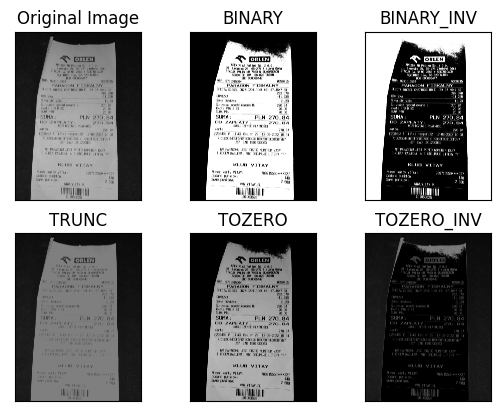

In [5]:
ret,thresh1 = cv2.threshold(image,127,255,cv2.THRESH_BINARY)
ret,thresh2 = cv2.threshold(image,127,255,cv2.THRESH_BINARY_INV)
ret,thresh3 = cv2.threshold(image,127,255,cv2.THRESH_TRUNC)
ret,thresh4 = cv2.threshold(image,127,255,cv2.THRESH_TOZERO)
ret,thresh5 = cv2.threshold(image,127,255,cv2.THRESH_TOZERO_INV)

titles = ['Original Image','BINARY','BINARY_INV','TRUNC','TOZERO','TOZERO_INV']
images = [image, thresh1, thresh2, thresh3, thresh4, thresh5]

for i in range(6):
    plt.subplot(2,3,i+1),plt.imshow(images[i],'gray',vmin=0,vmax=255)
    plt.title(titles[i])
    plt.xticks([]),plt.yticks([])
plt.show()


Convert image into text

In [18]:
def image_to_text(images: list):
    text_from_images = []
    for image in images:
        text = (pytesseract.image_to_string(image)).lower()
        text = text.split('\n')
        text = [sentence.strip() for sentence in text]
        text = [sentence for sentence in text if len(sentence) != 0]
        text_from_images.append(text)
    return text_from_images


In [19]:
texts = image_to_text(images)

Add new column to DataFrame

In [47]:

def new_col_dataframe(data_to_add: dict, df: pd.DataFrame):
    for key, value in data_to_add.items():
        new = pd.DataFrame()
        new[key] = value
        df = pd.concat([df, new], axis=1)
        
    return df

In [49]:
data = {
    "orginal": texts[0],
    "binary": texts[1],
    "binary_inv": texts[2],
    "trunc": texts[3],
    "tozero": texts[4],
    "tozero_inv": texts[5]
}

text_data = pd.DataFrame()
text_data = new_col_dataframe(data, text_data)


In [50]:
text_data

,orginal,binary,binary_inv,trunc,tozero,tozero_inv
0,= tt orlen,apexim ab paliwa sp. 20.0.,sat rr eet ee,apextm ab paliwa sp. z 0.0,apexim ab paliwa sp. 20.0.,"st, f patt tc 7 ra oe oo. —"
1,apexim ab paliwa sp. z 0.0.,"lwowska 25, 65-275 zielona gora","lwowska 25, 65-275 zielona gora",wowska 25 60-. 25 zielona gora,"lwowska 25, 65-275 zielona cera”",ree cie mera wall (es) coe
2,"{l. lwowska 25, 65-275 zielona gora",stacja paliw nr 7663 w sekowicach,shon wngt ren rca tine h,cja paliw nr 7663 w sekowicach,stacja paliw nr 7663 w sekowicach,stf ony) ey anh nr 7663 w sekowicach
3,stacja paliw nr 7663 w sekowicach,"sekowice 19a, 66-620 gubin","sekowice 19a, 66-620 gubin","~sekowice 194, 66-620 gubin","sekowice 19a, 66-620 gubin","sekowice 19a, 66-620 gubin"
4,"sekowice 19a, 66-620 gubin",boo 000066447,"st omnon net ty,",bdo go0066447,bdo 000066447,spor ete acy) vi
5,bdo 000066447,sint rece) opodat kowana b:,ee danner ar ee,5! 303 34 ws 3h ig,surceue opodat kowana b:,ee eee re | 270.84
6,nip: 9731015564 w359215,kwota ptu b 8%,kwota ptu b 8%,paragon f uskal ny,kwota ptu b 8%,vref iit aes) | 7
7,...... paragon fiskalny,suma ptu,suma ptu,cy,suma ptu,a pau
8,efecta diesel cn27102011d(4) (b) 37.46*7.53,do zaplaty— 3,do zaplaty— -,diesel cn27102011d(4) (b) 37.46*7.53,do zaplaty- os,se oz
9,ae 282.078,rozliczenie peatnosci,sore a azo,282 . 078,rozliczenie peatnosci,=?
